# Exp 4A — Long-context feasibility (V2, semantic edition)
**Question:** does the complete policy corpus fit into each model's context, what does it cost per claim, and is running it feasible at all? This decides which models and variants Exp 4B can use.

**Corpus variants:** *full* = all 22 policy documents verbatim (clauses + two paragraphs of interpretive commentary per clause); *lean* = the same documents with only the normative clause text (commentary removed).
**Method:** count characters and estimate tokens per document, then measure the real input tokens with one API call per model (paid models report `prompt_tokens`; Ollama reports `prompt_eval_count`), compare with each model's context limit, and project the cost per claim.
**No decision quality is measured here.** Cost of this notebook: about $0.02.

In [1]:
import json, os, re, sys
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[1]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, llm_exp
C.load_env()
pd.set_option('display.width', 220, 'display.max_columns', 30, 'display.max_colwidth', 80)
docs = sorted((C.POLICY/'source_documents').glob('*.md'))
def strip_commentary(text):
    out, lines, i = [], text.split('\n'), 0
    while i < len(lines):
        if lines[i].startswith('Interpretive guidance:'):
            i += 1
            while i < len(lines) and not lines[i].strip(): i += 1
            i += 1; continue           # skip the second commentary paragraph
        out.append(lines[i]); i += 1
    return re.sub(r'\n{3,}', '\n\n', '\n'.join(out))
FULL = '\n\n=====\n\n'.join(p.read_text(encoding='utf-8') for p in docs)
LEAN = '\n\n=====\n\n'.join(strip_commentary(p.read_text(encoding='utf-8')) for p in docs)
print(len(docs), 'documents | full', f'{len(FULL):,}', 'chars | lean', f'{len(LEAN):,}', 'chars')
print('clause headings kept in lean:', len(re.findall(r'^## \S+ - ', LEAN, re.M)), 'of', len(re.findall(r'^## \S+ - ', FULL, re.M)), '| commentary lines left in lean:', LEAN.count('Interpretive guidance'))

22 documents | full 272,587 chars | lean 64,602 chars
clause headings kept in lean: 229 of 229 | commentary lines left in lean: 0


## Size per document (estimate: characters / 4)

      doc  full_chars  lean_chars  full_tok_est  lean_tok_est  commentary_share
D01_GEP24       18540        3397          4635           849              0.82
D02_GEP25       19983        3771          4995           942              0.81
D03_GEP26       18548        4043          4637          1010              0.78
  D04_TRV       22201        5701          5550          1425              0.74
  D05_AIR        7674        1404          1918           351              0.82
  D06_GRD        7729        1360          1932           340              0.82
 D07_MEAL       14001        2823          3500           705              0.80
 D08_GIFT       11826        2318          2956           579              0.80
 D09_CARD        6720        1279          1680           319              0.81
  D10_APR       13936        2870          3484           717              0.79
  D11_EXC        7881        1487          1970           371              0.81
  D12_TRN       11841        2438       

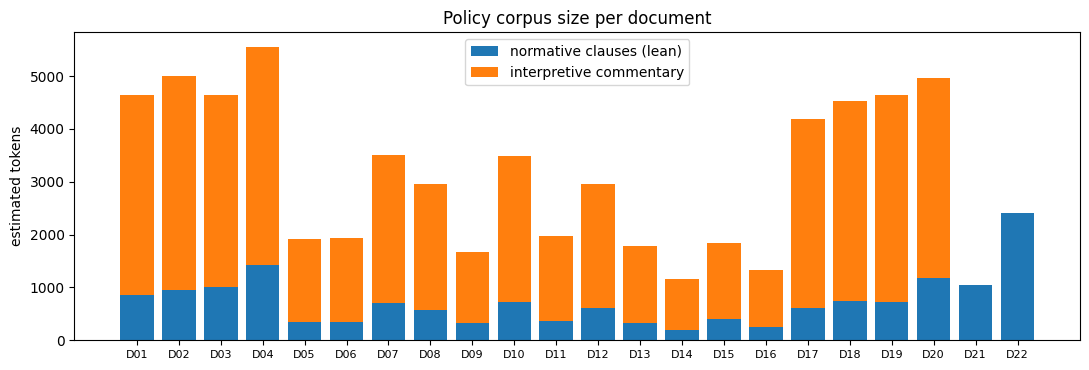

In [2]:
rows = []
for p in docs:
    t = p.read_text(encoding='utf-8'); l = strip_commentary(t); rows.append({'doc': p.stem, 'full_chars': len(t), 'lean_chars': len(l), 'full_tok_est': len(t)//4, 'lean_tok_est': len(l)//4, 'commentary_share': round(1 - len(l)/len(t), 2)})
sz = pd.DataFrame(rows); tot = sz[['full_chars','lean_chars','full_tok_est','lean_tok_est']].sum()
print(sz.to_string(index=False)); print('\nTOTAL', tot.to_dict(), '| commentary share of the full corpus:', round(1 - tot['lean_chars']/tot['full_chars'], 2))
fig, ax = plt.subplots(figsize=(11, 3.8)); x = np.arange(len(sz)); ax.bar(x, sz.lean_tok_est, label='normative clauses (lean)'); ax.bar(x, sz.full_tok_est - sz.lean_tok_est, bottom=sz.lean_tok_est, label='interpretive commentary')
ax.set_xticks(x); ax.set_xticklabels([d.split('_')[0] for d in sz.doc], fontsize=8); ax.set_ylabel('estimated tokens'); ax.set_title('Policy corpus size per document'); ax.legend(); plt.tight_layout()
(C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp04a_corpus_size.png', dpi=130); plt.show()

## Probe: real token counts per model (one claim + the corpus, tiny output)

In [3]:
MODELS = {'openai/gpt-4o-mini': 128_000, 'google/gemini-2.5-flash-lite': 1_048_576, 'llama3.2:3b': 131_072}   # advertised context limits
claim = "CLAIM:\n" + json.dumps(llm_exp.visible(llm_exp.cases_for('DEVELOPMENT')[0]), indent=1)
mk = lambda corpus: "You are ExpenseGuard. Use ONLY the policy corpus below.\n" + llm_exp.SCHEMA + "\n\nCOMPANY POLICY CORPUS:\n" + corpus
probe = []
for variant, corpus in (('lean', LEAN), ('full', FULL)):
    for m in MODELS:
        if m == 'llama3.2:3b':
            for ctx in ((16384, 24576) if variant == 'lean' else (16384, 65536)):
                llm.NUM_CTX = ctx
                try: r = llm.chat(m, [{'role':'system','content':mk(corpus)}, {'role':'user','content':claim}], tag='EXP04A', max_tokens=80); probe.append({'variant':variant,'model':m,'num_ctx':ctx,'prompt_tokens':r['input_tokens'],'latency_s':round(r['latency_ms']/1000,1),'cost_usd':0.0})
                except Exception as e: probe.append({'variant':variant,'model':m,'num_ctx':ctx,'prompt_tokens':None,'latency_s':None,'cost_usd':0.0, 'error':repr(e)[:80]})
            llm.NUM_CTX = 16384
        else:
            r = llm.chat(m, [{'role':'system','content':mk(corpus)}, {'role':'user','content':claim}], tag='EXP04A', max_tokens=80); probe.append({'variant':variant,'model':m,'num_ctx':None,'prompt_tokens':r['input_tokens'],'latency_s':round(r['latency_ms']/1000,1),'cost_usd':round(r['cost_usd'],5)})
pr = pd.DataFrame(probe); pr['limit'] = pr.model.map(MODELS)
ref = pr[pr.model == 'openai/gpt-4o-mini'].set_index('variant').prompt_tokens.to_dict()      # reference token count per variant
pr['truncated?'] = [bool(p is not None and n == n and n is not None and p < 0.9 * ref[v]) for p, n, v in zip(pr.prompt_tokens, pr.num_ctx, pr.variant)]
print(pr.to_string(index=False)); print('spent so far $%.4f' % llm.spent())

variant                        model  num_ctx  prompt_tokens  latency_s  cost_usd   limit  truncated?
   lean           openai/gpt-4o-mini      NaN          16592        2.8   0.00252  128000       False
   lean google/gemini-2.5-flash-lite      NaN          18893        1.3   0.00192 1048576       False
   lean                  llama3.2:3b  16384.0           8194       13.6   0.00000  131072        True
   lean                  llama3.2:3b  24576.0          16759       33.8   0.00000  131072       False
   full           openai/gpt-4o-mini      NaN          49095        5.3   0.00741  128000       False
   full google/gemini-2.5-flash-lite      NaN          51870        3.0   0.00522 1048576       False
   full                  llama3.2:3b  16384.0           8194       11.9   0.00000  131072        True
   full                  llama3.2:3b  65536.0          49683      243.7   0.00000  131072       False
spent so far $0.5778


## Feasibility and projected cost per claim
`fits` compares the measured prompt tokens with the model's advertised limit. For the local model, Ollama's `num_ctx` setting is what matters: with the default 16,384 the prompt is silently cut (`prompt_tokens` stops near 16k), which the probe shows for the full corpus.

In [4]:
PRICE = {'openai/gpt-4o-mini': (0.15, 0.60), 'google/gemini-2.5-flash-lite': (0.10, 0.40), 'llama3.2:3b': (0, 0)}
best = pr[pr.prompt_tokens.notna() & ~pr['truncated?']].sort_values('num_ctx', na_position='first').groupby(['variant','model']).head(1)   # smallest setting that is not truncated
out = []
for _, r in best.iterrows():
    pin, pout = PRICE[r.model]; per_claim_in = r.prompt_tokens + 350; cost = (per_claim_in * pin + 90 * pout) / 1e6
    ok = r.prompt_tokens <= r.limit and not r['truncated?']
    out.append({'variant': r.variant, 'model': r.model.split('/')[-1], 'prompt_tokens': int(r.prompt_tokens), 'context_limit': int(r.limit), 'fits': ok, 'num_ctx': r.num_ctx, 'probe_latency_s': r.latency_s, 'est hours for 70 dev': round(r.latency_s*70/3600, 2), 'cost/claim $': round(cost, 5), 'cost 70 dev $': round(cost*70, 3), 'cost 30 val $': round(cost*30, 3), 'cost 50 final $': round(cost*50, 3)})
feas = pd.DataFrame(out); print(feas.to_string(index=False))
plan_cost = feas[(feas.variant=='full') & (feas.model!='llama3.2:3b')]['cost 70 dev $'].sum() + feas[(feas.variant=='lean')]['cost 70 dev $'].sum()
print(feas[feas.model=='llama3.2:3b'][['variant','num_ctx','prompt_tokens','probe_latency_s','est hours for 70 dev']].to_string(index=False))
print('\nProjected Exp 4B cost (full: gpt-4o-mini + gemini on dev; lean: all three on dev): $%.3f | spent so far $%.4f of $%s' % (plan_cost, llm.spent(), os.environ['MAX_BUDGET_USD']))
feas.to_csv(C.RESULTS/'development'/'exp04a_feasibility.csv', index=False)

variant                 model  prompt_tokens  context_limit  fits  num_ctx  probe_latency_s  est hours for 70 dev  cost/claim $  cost 70 dev $  cost 30 val $  cost 50 final $
   lean           gpt-4o-mini          16592         128000  True      NaN              2.8                  0.05       0.00260          0.182          0.078            0.130
   lean gemini-2.5-flash-lite          18893        1048576  True      NaN              1.3                  0.03       0.00196          0.137          0.059            0.098
   full           gpt-4o-mini          49095         128000  True      NaN              5.3                  0.10       0.00747          0.523          0.224            0.374
   full gemini-2.5-flash-lite          51870        1048576  True      NaN              3.0                  0.06       0.00526          0.368          0.158            0.263
   lean           llama3.2:3b          16759         131072  True  24576.0             33.8                  0.66       0.000


variant  num_ctx  prompt_tokens  probe_latency_s  est hours for 70 dev
   lean  24576.0          16759             33.8                  0.66
   full  65536.0          49683            243.7                  4.74

Projected Exp 4B cost (full: gpt-4o-mini + gemini on dev; lean: all three on dev): $1.210 | spent so far $0.5778 of $3.50


## What was done and what it means
- **The corpus is large but it fits.** The full corpus (22 documents, 229 clauses) measures **49,095 tokens for gpt-4o-mini and 51,870 for gemini-2.5-flash-lite** (my characters/4 estimate of 68k was too high). Both are far below their limits (128k and about 1M). About 76% of the full corpus is the interpretive commentary; the normative clause text alone (lean) is **16,592 / 18,893 tokens**. The largest documents are the travel policy, circulars and the three regional addenda; the FAQ and historical schedules (documents that are retrieval distractors by design) are about 3.5k tokens together.
- **Cost per claim (input dominates):** about $0.0075 (gpt-4o-mini) and $0.0053 (gemini) for the full corpus, and $0.0026 / $0.0020 for lean. A 70-claim dev run costs about $0.52 / $0.37 (full) and $0.18 / $0.14 (lean); a 50-claim final test would cost $0.37 / $0.26 (full).
- **Local model (llama3.2:3b):** with our default 16,384-token window Ollama **silently truncates** the prompt to about 8.2k tokens (both corpora), so an unmodified setup would quietly ignore most of the policy. With a 24,576 window the lean corpus fits (16.8k tokens, about 34 s per claim, 0.7 hours for 70 claims). The full corpus fits only with a 65,536 window and takes about 244 s per claim (about 4.7 hours for 70 claims), so it is excluded from 4B.
- **Two fixes made along the way:** the local-model cache key now includes a non-default context window (my first probe had hit a stale cache entry), and `llm.NUM_CTX` is now a setting instead of a constant. Earlier local runs used the default window and their cache keys are unchanged.
- **Decision:** 4B proceeds with the full corpus on gpt-4o-mini and gemini, and the lean corpus on all three models, dev split only. Projected cost about $1.21, leaving about $1.7 of the $3.50 cap before 4B's own spend.